In [4]:
# Import data handling libraries
import pandas as pd
import numpy as np

# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Import ML preprocessing tools
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Ignore unnecessary warnings
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully")

Libraries imported successfully


In [5]:
# Load the 4 CSV files from the raw data folder
student_info         = pd.read_csv('../data/raw/studentInfo.csv')
student_assessment   = pd.read_csv('../data/raw/studentAssessment.csv')
student_registration = pd.read_csv('../data/raw/studentRegistration.csv')
student_vle          = pd.read_csv('../data/raw/studentVle.csv')

# Print the shape (rows, columns) of each file to confirm loading
print(f"studentInfo shape:         {student_info.shape}")
print(f"studentAssessment shape:   {student_assessment.shape}")
print(f"studentRegistration shape: {student_registration.shape}")
print(f"studentVle shape:          {student_vle.shape}")

studentInfo shape:         (32593, 12)
studentAssessment shape:   (173912, 5)
studentRegistration shape: (32593, 5)
studentVle shape:          (10655280, 6)


In [6]:
# Explore the main file - studentInfo
# This file contains our target variable (final_result)
print("=== First 5 rows of studentInfo ===")
print(student_info.head())

print("\n=== Column names ===")
print(student_info.columns.tolist())

print("\n=== Data types of each column ===")
print(student_info.dtypes)

print("\n=== Missing values in each column ===")
print(student_info.isnull().sum())

=== First 5 rows of studentInfo ===
  code_module code_presentation  id_student gender                region  \
0         AAA             2013J       11391      M   East Anglian Region   
1         AAA             2013J       28400      F              Scotland   
2         AAA             2013J       30268      F  North Western Region   
3         AAA             2013J       31604      F     South East Region   
4         AAA             2013J       32885      F  West Midlands Region   

       highest_education imd_band age_band  num_of_prev_attempts  \
0       HE Qualification  90-100%     55<=                     0   
1       HE Qualification   20-30%    35-55                     0   
2  A Level or Equivalent   30-40%    35-55                     0   
3  A Level or Equivalent   50-60%    35-55                     0   
4     Lower Than A Level   50-60%     0-35                     0   

   studied_credits disability final_result  
0              240          N         Pass  
1       

=== Target variable distribution ===
final_result
Pass           12361
Withdrawn      10156
Fail            7052
Distinction     3024
Name: count, dtype: int64

=== Percentage breakdown ===
final_result
Pass           37.925321
Withdrawn      31.160065
Fail           21.636548
Distinction     9.278066
Name: proportion, dtype: float64



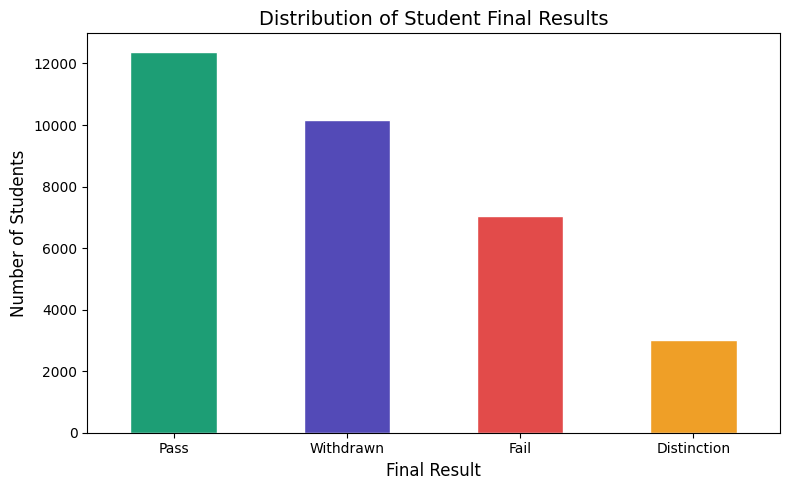

Chart saved to report folder


In [7]:
# Check the distribution of our target variable - final_result
print("=== Target variable distribution ===")
print(student_info['final_result'].value_counts())
print()

# Calculate percentage of each class
print("=== Percentage breakdown ===")
print(student_info['final_result'].value_counts(normalize=True) * 100)
print()

# Plot the distribution as a bar chart
plt.figure(figsize=(8, 5))
colors = ['#1D9E75', '#534AB7', '#E24B4A', '#EF9F27']
student_info['final_result'].value_counts().plot(
    kind='bar', 
    color=colors,
    edgecolor='white'
)
plt.title('Distribution of Student Final Results', fontsize=14)
plt.xlabel('Final Result', fontsize=12)
plt.ylabel('Number of Students', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../report/01_target_distribution.png', dpi=150)
plt.show()
print("Chart saved to report folder")

In [8]:
# ── Quick EDA on studentAssessment ──────────────────────────
print("=== studentAssessment - first 3 rows ===")
print(student_assessment.head(3))
print(f"\nMissing values:\n{student_assessment.isnull().sum()}")
print(f"\nScore statistics:\n{student_assessment['score'].describe()}")

=== studentAssessment - first 3 rows ===
   id_assessment  id_student  date_submitted  is_banked score
0           1752       11391              18          0    78
1           1752       28400              22          0    70
2           1752       31604              17          0    72

Missing values:
id_assessment     0
id_student        0
date_submitted    0
is_banked         0
score             0
dtype: int64

Score statistics:
count     173912
unique       102
top          100
freq       18813
Name: score, dtype: object


In [9]:
# Diagnose the score column
print("Sample values in score column:")
print(student_assessment['score'].unique()[:20])
print()
print(f"Current dtype: {student_assessment['score'].dtype}")

Sample values in score column:
<StringArray>
['78', '70', '72', '69', '79', '71', '68', '73', '67', '83', '66', '59', '82',
 '60', '75', '74', '62', '63', '84', '80']
Length: 20, dtype: str

Current dtype: str


In [10]:
# Fix: score column is stored as StringArray dtype
# Need to convert to regular Python string first, then to number

student_assessment['score'] = student_assessment['score'].astype(str).replace('nan', np.nan)
student_assessment['score'] = pd.to_numeric(student_assessment['score'], errors='coerce')

# Verify fix
print("=== Score column AFTER fixing ===")
print(student_assessment['score'].describe())
print()
print(f"Missing scores: {student_assessment['score'].isnull().sum()}")
print(f"dtype is now:   {student_assessment['score'].dtype}")

=== Score column AFTER fixing ===
count    173739.000000
mean         75.799573
std          18.798107
min           0.000000
25%          65.000000
50%          80.000000
75%          90.000000
max         100.000000
Name: score, dtype: float64

Missing scores: 173
dtype is now:   float64


In [11]:
# Investigate the 173 missing score rows
missing_scores = student_assessment[student_assessment['score'].isnull()]

print(f"Total missing score rows: {len(missing_scores)}")
print()
print("=== Missing score rows - student IDs ===")
print(missing_scores[['id_student', 'id_assessment', 'date_submitted']].head(20))
print()

# Check what final_result these students have in studentInfo
missing_student_ids = missing_scores['id_student'].unique()
print(f"Unique students with missing scores: {len(missing_student_ids)}")
print()

# Cross check with studentInfo to see their final result
missing_students_info = student_info[
    student_info['id_student'].isin(missing_student_ids)
][['id_student', 'final_result']]

print("=== Final result of students with missing scores ===")
print(missing_students_info['final_result'].value_counts())

Total missing score rows: 173

=== Missing score rows - student IDs ===
       id_student  id_assessment  date_submitted
215        721259           1752              22
937        260355           1754             127
2364      2606802           1760             180
3358       186780          14984              77
3914       531205          14984              26
3943       534151          14984               7
4206       549713          14984              84
4311       554393          14984              55
4753       186780          14985              77
5722        33666          14986             117
6124       511527          14986             138
6527       554818          14986             146
7129       484039          14987             137
7574       554818          14987             150
7930       262294          14988             152
8517       554818          14988             158
8777       478317          14989             222
8847       502717          14989             2

In [13]:
# Create assessment features per student
print("Creating assessment features per student...")

assessment_features = student_assessment.groupby('id_student').agg(
    avg_score       = ('score', 'mean'),   # average score across all assessments
    total_score     = ('score', 'sum'),    # total marks earned
    submission_count= ('score', 'count')   # how many assessments submitted
).reset_index()

print(f"Assessment features shape: {assessment_features.shape}")
print()
print("=== Sample assessment features ===")
print(assessment_features.head())
print()
print("=== Missing values ===")
print(assessment_features.isnull().sum())

Creating assessment features per student...
Assessment features shape: (23369, 4)

=== Sample assessment features ===
   id_student  avg_score  total_score  submission_count
0        6516  61.800000        309.0                 5
1        8462  87.000000        609.0                 7
2       11391  82.000000        410.0                 5
3       23629  82.500000        330.0                 4
4       23698  74.444444        670.0                 9

=== Missing values ===
id_student           0
avg_score           18
total_score          0
submission_count     0
dtype: int64


In [14]:
# ── Quick EDA on studentRegistration ────────────────────────
print("=== studentRegistration - first 3 rows ===")
print(student_registration.head(3))
print(f"\nColumns: {student_registration.columns.tolist()}")
print(f"\nMissing values:\n{student_registration.isnull().sum()}")

print("\n" + "="*50 + "\n")

# ── Quick EDA on studentVle ──────────────────────────────────
print("=== studentVle - first 3 rows ===")
print(student_vle.head(3))
print(f"\nColumns: {student_vle.columns.tolist()}")
print(f"\nMissing values:\n{student_vle.isnull().sum()}")
print(f"\nClick statistics:\n{student_vle['sum_click'].describe()}")

=== studentRegistration - first 3 rows ===
  code_module code_presentation  id_student date_registration  \
0         AAA             2013J       11391              -159   
1         AAA             2013J       28400               -53   
2         AAA             2013J       30268               -92   

  date_unregistration  
0                   ?  
1                   ?  
2                  12  

Columns: ['code_module', 'code_presentation', 'id_student', 'date_registration', 'date_unregistration']

Missing values:
code_module            0
code_presentation      0
id_student             0
date_registration      0
date_unregistration    0
dtype: int64


=== studentVle - first 3 rows ===
  code_module code_presentation  id_student  id_site  date  sum_click
0         AAA             2013J       28400   546652   -10          4
1         AAA             2013J       28400   546652   -10          1
2         AAA             2013J       28400   546652   -10          1

Columns: ['code_module'

In [15]:
# ══════════════════════════════════════════════════════════════
# FEATURE ENGINEERING
# ══════════════════════════════════════════════════════════════

# ── Feature 1: VLE Click Features from studentVle ────────────
# Aggregate 10.6 million rows into 3 numbers per student

print("Creating VLE features...")

vle_features = student_vle.groupby('id_student').agg(
    total_clicks  = ('sum_click', 'sum'),   # total clicks across entire course
    days_active   = ('date', 'nunique'),    # number of unique days student logged in
    avg_daily_clicks = ('sum_click', 'mean') # average clicks per day
).reset_index()

print(f"VLE features shape: {vle_features.shape}")
print()
print("=== Sample VLE features ===")
print(vle_features.head())
print()
print("=== VLE feature statistics ===")
print(vle_features.describe())

Creating VLE features...
VLE features shape: (26074, 4)

=== Sample VLE features ===
   id_student  total_clicks  days_active  avg_daily_clicks
0        6516          2791          159          4.216012
1        8462           656           56          2.157895
2       11391           934           40          4.765306
3       23629           161           16          2.728814
4       23698           910           70          2.983607

=== VLE feature statistics ===
         id_student  total_clicks   days_active  avg_daily_clicks
count  2.607400e+04  26074.000000  26074.000000      26074.000000
mean   7.087453e+05   1518.949873     66.618355          3.277612
std    5.529544e+05   1935.994635     56.632912          1.196497
min    6.516000e+03      1.000000      1.000000          1.000000
25%    5.067170e+05    298.000000     21.000000          2.382609
50%    5.901150e+05    824.000000     52.000000          3.095676
75%    6.459182e+05   2018.000000     99.000000          4.000000
m

In [16]:
# ── Feature 2: Assessment Features from studentAssessment ────
# Create meaningful score features per student

print("Creating assessment features...")

assessment_features = student_assessment.groupby('id_student').agg(
    avg_score        = ('score', 'mean'),  # average score across assessments
    total_score      = ('score', 'sum'),   # total marks earned
    submission_count = ('score', 'count'), # number of assessments submitted
    min_score        = ('score', 'min'),   # lowest score (shows struggling)
    max_score        = ('score', 'max')    # highest score (shows potential)
).reset_index()

print(f"Assessment features shape: {assessment_features.shape}")
print()
print("=== Sample assessment features ===")
print(assessment_features.head())
print()
print("=== Assessment feature statistics ===")
print(assessment_features.describe())

Creating assessment features...
Assessment features shape: (23369, 6)

=== Sample assessment features ===
   id_student  avg_score  total_score  submission_count  min_score  max_score
0        6516  61.800000        309.0                 5       48.0       77.0
1        8462  87.000000        609.0                 7       83.0       93.0
2       11391  82.000000        410.0                 5       78.0       85.0
3       23629  82.500000        330.0                 4       63.0      100.0
4       23698  74.444444        670.0                 9       56.0       94.0

=== Assessment feature statistics ===
         id_student     avg_score   total_score  submission_count  \
count  2.336900e+04  23351.000000  23369.000000      23369.000000   
mean   7.091426e+05     73.142603    563.538962          7.434593   
std    5.556415e+05     15.541069    353.896258          4.225845   
min    6.516000e+03      0.000000      0.000000          0.000000   
25%    5.046020e+05     65.000000    279.0

In [17]:
# ── Feature 3: Registration Features from studentRegistration ─
# Extract withdrawal information per student
# Remember: date_unregistration = "?" means still enrolled (not withdrawn)

print("Creating registration features...")

# Replace "?" with NaN — "?" means student did NOT withdraw
student_registration['date_unregistration'] = student_registration[
    'date_unregistration'
].replace('?', np.nan)

# Create withdrew_early feature
# 1 = student withdrew during the course
# 0 = student completed the course (no unregistration date)
registration_features = student_registration.groupby('id_student').agg(
    withdrew_early = ('date_unregistration', lambda x: 1 if x.notna().any() else 0)
).reset_index()

print(f"Registration features shape: {registration_features.shape}")
print()
print("=== Withdrawal distribution ===")
print(registration_features['withdrew_early'].value_counts())
print()
print("=== Sample registration features ===")
print(registration_features.head())

Creating registration features...
Registration features shape: (28785, 2)

=== Withdrawal distribution ===
withdrew_early
0    19703
1     9082
Name: count, dtype: int64

=== Sample registration features ===
   id_student  withdrew_early
0        3733               1
1        6516               0
2        8462               1
3       11391               0
4       23629               0


In [18]:
# ══════════════════════════════════════════════════════════════
# MERGING ALL FILES INTO ONE DATAFRAME
# ══════════════════════════════════════════════════════════════
# Base: studentInfo (32,593 rows)
# We use LEFT JOIN — keeps all 32,593 students
# Students with no VLE/assessment data get NaN → filled with 0

print("Merging all files...")

# Step 1 — Start with studentInfo as base
df = student_info.copy()
print(f"Base shape: {df.shape}")

# Step 2 — Merge VLE features
df = df.merge(vle_features, on='id_student', how='left')
print(f"After VLE merge: {df.shape}")

# Step 3 — Merge assessment features
df = df.merge(assessment_features, on='id_student', how='left')
print(f"After assessment merge: {df.shape}")

# Step 4 — Merge registration features
df = df.merge(registration_features, on='id_student', how='left')
print(f"After registration merge: {df.shape}")

print()
print("=== Final merged dataframe columns ===")
print(df.columns.tolist())
print()
print("=== Missing values after merge ===")
print(df.isnull().sum())

Merging all files...
Base shape: (32593, 12)
After VLE merge: (32593, 15)
After assessment merge: (32593, 20)
After registration merge: (32593, 21)

=== Final merged dataframe columns ===
['code_module', 'code_presentation', 'id_student', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result', 'total_clicks', 'days_active', 'avg_daily_clicks', 'avg_score', 'total_score', 'submission_count', 'min_score', 'max_score', 'withdrew_early']

=== Missing values after merge ===
code_module                0
code_presentation          0
id_student                 0
gender                     0
region                     0
highest_education          0
imd_band                   0
age_band                   0
num_of_prev_attempts       0
studied_credits            0
disability                 0
final_result               0
total_clicks            2852
days_active             2852
avg_daily_clicks        2852
avg_score

In [20]:
# ══════════════════════════════════════════════════════════════
# FILL MISSING VALUES AFTER MERGE
# ══════════════════════════════════════════════════════════════
# No data leakage — we do NOT use final_result here
# Logic:
# VLE missing    → student never logged in → 0
# Score missing  → student never submitted → 0
# withdrew_early → already 0 for all (no missing)

print("Missing values BEFORE filling:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print()

# Fill VLE features — student never logged in = 0 clicks
df['total_clicks']     = df['total_clicks'].fillna(0)
df['days_active']      = df['days_active'].fillna(0)
df['avg_daily_clicks'] = df['avg_daily_clicks'].fillna(0)

# Fill assessment features — student never submitted = 0
df['avg_score']        = df['avg_score'].fillna(0)
df['total_score']      = df['total_score'].fillna(0)
df['submission_count'] = df['submission_count'].fillna(0)
df['min_score']        = df['min_score'].fillna(0)
df['max_score']        = df['max_score'].fillna(0)

print("Missing values AFTER filling:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print()
print(f"Total missing values: {df.isnull().sum().sum()}")
print("All missing values handled!")

Missing values BEFORE filling:
Series([], dtype: int64)

Missing values AFTER filling:
Series([], dtype: int64)

Total missing values: 0
All missing values handled!


Creating target variable...

=== Original final_result distribution ===
final_result
Pass           12361
Withdrawn      10156
Fail            7052
Distinction     3024
Name: count, dtype: int64

=== Binary dropout distribution ===
dropout
1    17208
0    15385
Name: count, dtype: int64

Dropout rate: 52.8%
Non-dropout rate: 47.2%



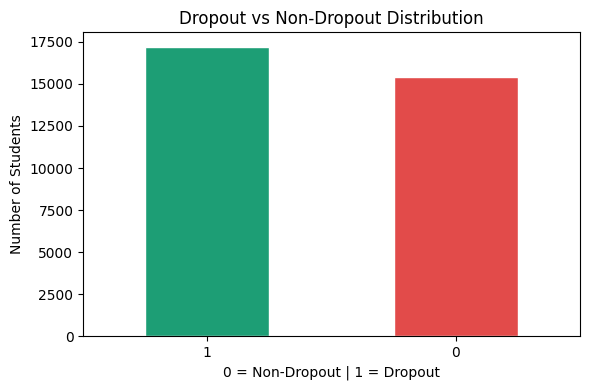

Target variable created!


In [21]:
# ══════════════════════════════════════════════════════════════
# CREATE TARGET VARIABLE
# ══════════════════════════════════════════════════════════════
# Convert final_result into binary dropout column
# Dropout (1) = Fail or Withdrawn
# Non-Dropout (0) = Pass or Distinction

print("Creating target variable...")
print()

# Show original distribution
print("=== Original final_result distribution ===")
print(df['final_result'].value_counts())
print()

# Create binary target column
df['dropout'] = df['final_result'].apply(
    lambda x: 1 if x in ['Fail', 'Withdrawn'] else 0
)

# Show new target distribution
print("=== Binary dropout distribution ===")
print(df['dropout'].value_counts())
print()
print(f"Dropout rate: {df['dropout'].mean()*100:.1f}%")
print(f"Non-dropout rate: {(1-df['dropout'].mean())*100:.1f}%")
print()

# Visualize
plt.figure(figsize=(6,4))
df['dropout'].value_counts().plot(
    kind='bar',
    color=['#1D9E75','#E24B4A'],
    edgecolor='white'
)
plt.title('Dropout vs Non-Dropout Distribution')
plt.xlabel('0 = Non-Dropout | 1 = Dropout')
plt.ylabel('Number of Students')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../report/02_dropout_distribution.png', dpi=150)
plt.show()
print("Target variable created!")

In [22]:
# ══════════════════════════════════════════════════════════════
# DROP UNNECESSARY COLUMNS
# ══════════════════════════════════════════════════════════════
# Remove columns that are not useful for prediction:
# - code_module: course code - not meaningful for dropout prediction
# - code_presentation: semester code - not meaningful
# - id_student: just an ID number - not a feature
# - final_result: replaced by our dropout column

print("Columns before dropping:")
print(df.columns.tolist())
print(f"Shape before: {df.shape}")
print()

# Drop unnecessary columns
df = df.drop(columns=[
    'code_module',        # course code - not useful
    'code_presentation',  # semester - not useful
    'id_student',         # just an ID
    'final_result'        # replaced by dropout column
])

print("Columns after dropping:")
print(df.columns.tolist())
print(f"Shape after: {df.shape}")
print()
print("Unnecessary columns removed!")

Columns before dropping:
['code_module', 'code_presentation', 'id_student', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result', 'total_clicks', 'days_active', 'avg_daily_clicks', 'avg_score', 'total_score', 'submission_count', 'min_score', 'max_score', 'withdrew_early', 'dropout']
Shape before: (32593, 22)

Columns after dropping:
['gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'total_clicks', 'days_active', 'avg_daily_clicks', 'avg_score', 'total_score', 'submission_count', 'min_score', 'max_score', 'withdrew_early', 'dropout']
Shape after: (32593, 18)

Unnecessary columns removed!


In [23]:
# ══════════════════════════════════════════════════════════════
# ENCODING — Convert text columns to numbers
# ══════════════════════════════════════════════════════════════
# ML models only understand numbers — not text
# We use LabelEncoder — converts each unique text to a number

print("Columns before encoding:")
print(df.dtypes)
print()

# Identify text columns to encode
text_columns = [
    'gender',            # M/F → 0/1
    'region',            # region names → 0-13
    'highest_education', # education level → 0-4
    'imd_band',          # deprivation band → 0-10
    'age_band',          # age range → 0-2
    'disability'         # Y/N → 0/1
]

# Apply LabelEncoder to each text column
le = LabelEncoder()
for col in text_columns:
    df[col] = le.fit_transform(df[col])
    print(f"Encoded {col}")

print()
print("=== Data types after encoding ===")
print(df.dtypes)
print()
print("=== Sample data after encoding ===")
print(df.head())
print()
print("Encoding complete!")

Columns before encoding:
gender                      str
region                      str
highest_education           str
imd_band                    str
age_band                    str
num_of_prev_attempts      int64
studied_credits           int64
disability                  str
total_clicks            float64
days_active             float64
avg_daily_clicks        float64
avg_score               float64
total_score             float64
submission_count        float64
min_score               float64
max_score               float64
withdrew_early            int64
dropout                   int64
dtype: object

Encoded gender
Encoded region
Encoded highest_education
Encoded imd_band
Encoded age_band
Encoded disability

=== Data types after encoding ===
gender                    int64
region                    int64
highest_education         int64
imd_band                  int64
age_band                  int64
num_of_prev_attempts      int64
studied_credits           int64
disability      

Analyzing feature correlations with dropout...

=== Feature correlation with dropout ===
dropout                 1.000000
withdrew_early          0.583453
studied_credits         0.138630
highest_education       0.108162
num_of_prev_attempts    0.105460
disability              0.059477
gender                  0.022428
region                  0.005803
age_band               -0.068695
imd_band               -0.144878
avg_daily_clicks       -0.325667
total_clicks           -0.411574
min_score              -0.429217
days_active            -0.556260
avg_score              -0.558808
max_score              -0.566030
submission_count       -0.612396
total_score            -0.651046
Name: dropout, dtype: float64



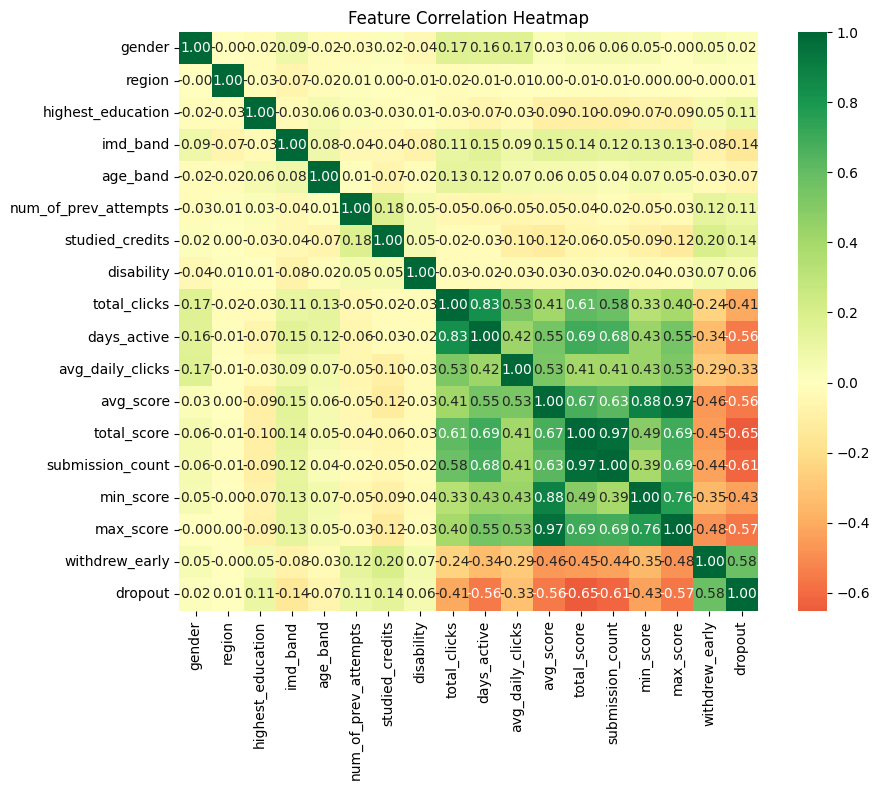

Correlation heatmap saved!


In [24]:
# ══════════════════════════════════════════════════════════════
# FEATURE SELECTION — Correlation Analysis
# ══════════════════════════════════════════════════════════════
# Check which features are most correlated with dropout
# High correlation = useful feature
# Low correlation = might remove it

print("Analyzing feature correlations with dropout...")
print()

# Calculate correlation of each feature with dropout target
correlation = df.corr()['dropout'].sort_values(ascending=False)

print("=== Feature correlation with dropout ===")
print(correlation)
print()

# Plot correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    df.corr(),
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    square=True
)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('../report/03_correlation_heatmap.png', dpi=150)
plt.show()
print("Correlation heatmap saved!")

In [25]:
# ══════════════════════════════════════════════════════════════
# FEATURE SELECTION — Remove weak features
# ══════════════════════════════════════════════════════════════
# Based on correlation analysis:
# region     = 0.006 → nearly zero correlation → remove
# gender     = 0.022 → very weak correlation   → remove
# disability = 0.059 → weak correlation        → remove

print("Removing weak features based on correlation analysis...")
print(f"Shape before: {df.shape}")

# Drop weak features
df = df.drop(columns=['region', 'gender', 'disability'])

print(f"Shape after:  {df.shape}")
print()
print("=== Remaining features ===")
print(df.columns.tolist())
print()

# Separate features (X) and target (y)
X = df.drop(columns=['dropout'])
y = df['dropout']

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape:   {y.shape}")
print()
print(f"Feature names: {X.columns.tolist()}")
print("Feature selection complete!")

Removing weak features based on correlation analysis...
Shape before: (32593, 18)
Shape after:  (32593, 15)

=== Remaining features ===
['highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'total_clicks', 'days_active', 'avg_daily_clicks', 'avg_score', 'total_score', 'submission_count', 'min_score', 'max_score', 'withdrew_early', 'dropout']

Features (X) shape: (32593, 14)
Target (y) shape:   (32593,)

Feature names: ['highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'total_clicks', 'days_active', 'avg_daily_clicks', 'avg_score', 'total_score', 'submission_count', 'min_score', 'max_score', 'withdrew_early']
Feature selection complete!


In [26]:
# ══════════════════════════════════════════════════════════════
# SCALING — For KNN only
# ══════════════════════════════════════════════════════════════
# Decision Tree, Random Forest, XGBoost → do NOT need scaling
# KNN → NEEDS scaling because it uses distance calculations
# Large values like total_clicks (28,615) would dominate
# small values like age_band (0,1,2) without scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Scale features for KNN
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("=== Original values (first row) ===")
print(X.iloc[0])
print()
print("=== Scaled values (first row) ===")
print(X_scaled.iloc[0])
print()
print(f"X shape:        {X.shape}")
print(f"X_scaled shape: {X_scaled.shape}")
print("Scaling complete!")
print()
print("Note: X_scaled used for KNN only")
print("      X (unscaled) used for Decision Tree, Random Forest, XGBoost")

=== Original values (first row) ===
highest_education         1.000000
imd_band                  9.000000
age_band                  2.000000
num_of_prev_attempts      0.000000
studied_credits         240.000000
total_clicks            934.000000
days_active              40.000000
avg_daily_clicks          4.765306
avg_score                82.000000
total_score             410.000000
submission_count          5.000000
min_score                78.000000
max_score                85.000000
withdrew_early            0.000000
Name: 0, dtype: float64

=== Scaled values (first row) ===
highest_education      -0.023322
imd_band                1.551053
age_band                3.583731
num_of_prev_attempts   -0.340229
studied_credits         3.901543
total_clicks           -0.270978
days_active            -0.399308
avg_daily_clicks        1.197529
avg_score               0.711168
total_score            -0.169197
submission_count       -0.266749
min_score               1.171308
max_score          